# Telco Customer Churn Analysis

Kaggle의 통신사 고객 이탈 데이터를 활용해 이탈 패턴을 탐색하고,
전처리 및 시각화를 통해 핵심 인사이트를 도출하는 분석 프로젝트입니다.

## 분석 흐름

1. 데이터셋 소개
2. 라이브러리 및 환경 설정
3. 데이터 로드
4. 탐색적 데이터 분석 (EDA)
5. 데이터 전처리
6. 시각화
7. 결론

## 1. 데이터셋 소개

[Kaggle Dataset: Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

통신사 고객 7,043명의 이용 정보를 바탕으로 이탈(`Churn`) 여부를 분석합니다.
신규 고객 유치 비용은 기존 고객 유지 비용보다 **5~25배** 더 높기 때문에,
이탈 징후를 사전에 포착해 선제적 대응 전략을 수립하는 것이 이 분석의 목적입니다.

> 데이터 파일은 위 Kaggle 링크에서 직접 다운로드 후 `./data/` 폴더에 저장하세요.

### 주요 컬럼 설명

| 컬럼 | 설명 |
|------|------|
| `customerID` | 고객 고유 식별자 |
| `gender` | 성별 |
| `SeniorCitizen` | 고령자 여부 (1, 0) |
| `Partner` | 파트너 유무 |
| `Dependents` | 부양가족 유무 |
| `tenure` | 가입 기간 (개월) |
| `PhoneService` | 전화 서비스 이용 여부 |
| `MultipleLines` | 다중 회선 여부 |
| `InternetService` | 인터넷 서비스 종류 |
| `OnlineSecurity` | 온라인 보안 서비스 여부 |
| `OnlineBackup` | 온라인 백업 서비스 여부 |
| `DeviceProtection` | 기기 보호 서비스 여부 |
| `TechSupport` | 기술 지원 서비스 여부 |
| `StreamingTV` | TV 스트리밍 서비스 여부 |
| `StreamingMovies` | 영화 스트리밍 서비스 여부 |
| `Contract` | 계약 유형 |
| `PaperlessBilling` | 전자 청구서 여부 |
| `PaymentMethod` | 결제 방법 |
| `MonthlyCharges` | 월 요금 |
| `TotalCharges` | 누적 요금 |
| `Churn` | 고객 이탈 여부 (Target) |

## 2. 라이브러리 및 환경 설정

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 전체 시각화 스타일
sns.set_theme(style="whitegrid")

# Churn 색상 기준: 0(유지) = 파랑, 1(이탈) = 빨강
CHURN_PALETTE = {0: "#3B82F6", 1: "#EF4444"}
CHURN_COLORS = ["#3B82F6", "#EF4444"]

# 폰트 크기 기준 통일
plt.rcParams.update({
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

# README 이미지 저장 폴더
os.makedirs("./images", exist_ok=True)

## 3. 데이터 로드

In [2]:
df = pd.read_csv("./data/cust_data_v1.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,NaN,0.0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,NaN,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0.0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0.0,No,No,2,Yes,No,DSL,Yes,...,NaN,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0.0,No,No,45,No,No phone service,DSL,Yes,...,NaN,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0.0,No,No,2,Yes,No,Fiber optic,No,...,NaN,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. 탐색적 데이터 분석 (EDA)

### 4.1 데이터 기본 정보 확인

컬럼 타입, 인덱스, 결측치 여부 등 전체적인 데이터 상태를 파악합니다.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7034 non-null   object 
 2   SeniorCitizen     7042 non-null   float64
 3   Partner           7043 non-null   object 
 4   Dependents        7041 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7040 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  3580 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7042 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7042.000000,7043.000000,7042.000000
mean,0.162170,32.371149,64.763256
std,0.368633,24.559481,30.091898
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### 4.2 Churn 분포 확인

타깃 변수의 클래스 불균형 여부를 먼저 확인합니다.

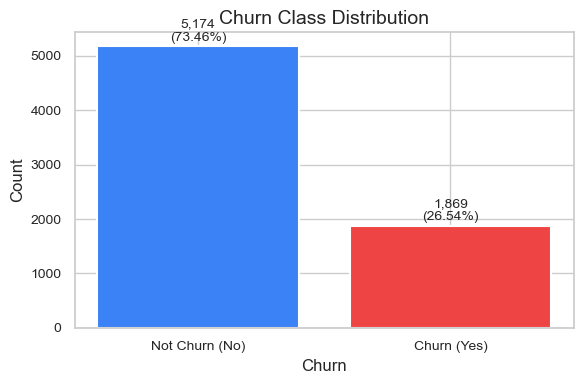

In [6]:
churn_counts = df.groupby("Churn").size()
churn_ratio = (churn_counts / churn_counts.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Not Churn (No)", "Churn (Yes)"],
              churn_counts.values,
              color=CHURN_COLORS, edgecolor="white", linewidth=1.5)

for bar, count, ratio in zip(bars, churn_counts.values, churn_ratio.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 50,
            f"{count:,}\n({ratio}%)",
            ha="center", va="bottom", fontsize=10)

ax.set_title("Churn Class Distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("./images/churn_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.3 결측치 분석

컬럼별 결측치 수와 비율을 파악한 뒤 처리 방법을 결정합니다.

In [7]:
null_info = pd.DataFrame({
    "Null Count": df.isnull().sum(),
    "Null %": (df.isnull().sum() / len(df) * 100).round(2)
})
null_info[null_info["Null Count"] > 0].sort_values("Null %", ascending=False)

,Null Count,Null %
DeviceProtection,3463,49.17
gender,9,0.13
PhoneService,3,0.04
Dependents,2,0.03
SeniorCitizen,1,0.01
Contract,1,0.01
PaymentMethod,1,0.01
MonthlyCharges,1,0.01


이탈 여부에 따라 결측치 분포가 다른지 확인합니다. 편향이 없으면 전처리 방식에 영향을 주지 않습니다.

In [8]:
print(df.groupby("Churn").apply(lambda x: x.isnull().sum()))

       customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
Churn                                                                   
No              0       8              1        0           2       0   
Yes             0       1              0        0           0       0   

       PhoneService  MultipleLines  InternetService  OnlineSecurity  ...  \
Churn                                                                ...   
No                1              0                0               0  ...   
Yes               2              0                0               0  ...   

       DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
Churn                                                                          
No                 2529            0            0                0         1   
Yes                 934            0            0                0         0   

       PaperlessBilling  PaymentMethod  MonthlyCharges  TotalCharges  Churn  
Chu

C:\Users\Admin\AppData\Local\Temp\ipykernel_14444\3118922108.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(df.groupby("Churn").apply(lambda x: x.isnull().sum()))


## 5. 데이터 전처리

### 5.1 불필요한 컬럼 제거

식별자 컬럼(`customerID`)은 분석에 활용되지 않으므로 제거합니다.

In [9]:
df_new = df.drop(columns="customerID")
print(df_new.shape)

(7043, 20)


### 5.2 DeviceProtection 결측치 분석

결측 여부가 이탈률에 영향을 주는지 시각화로 먼저 확인합니다.
결측과 무관하게 이탈 비율이 동일하다면 컬럼 전체를 제거합니다.

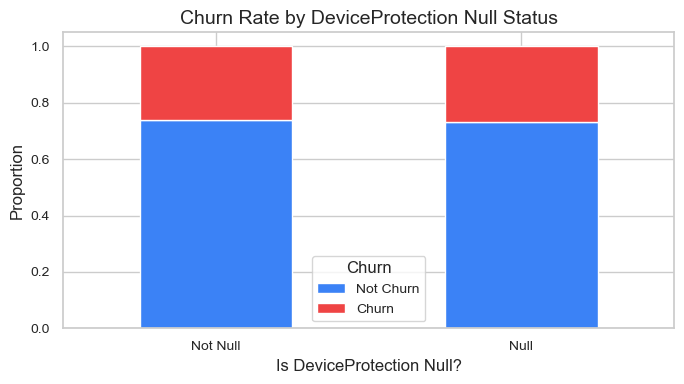

In [10]:
df_new["Is_DP_Null"] = df_new["DeviceProtection"].isnull().astype(str)
null_churn_dist = df_new.groupby("Is_DP_Null")["Churn"].value_counts(normalize=True).unstack()

fig, ax = plt.subplots(figsize=(7, 4))
null_churn_dist.plot(kind="bar", stacked=True, color=CHURN_COLORS, ax=ax)
ax.set_title("Churn Rate by DeviceProtection Null Status")
ax.set_xlabel("Is DeviceProtection Null?")
ax.set_ylabel("Proportion")
ax.set_xticklabels(["Not Null", "Null"], rotation=0)
ax.legend(title="Churn", labels=["Not Churn", "Churn"])
plt.tight_layout()
plt.show()

결측 여부와 무관하게 이탈 비율이 약 3:1로 동일 → 컬럼 변별력 없음 → drop

In [11]:
df_new.drop(columns=["DeviceProtection", "Is_DP_Null"], inplace=True)

### 5.3 이탈률 차이 미미한 컬럼 제거

카테고리별 이탈률 편차가 작은 컬럼은 예측에 기여도가 낮으므로 제거합니다.

In [12]:
cat_cols = df_new.select_dtypes(include=["object"]).columns
results = []

for col in cat_cols:
    if col == "Churn":
        continue
    # Churn이 Yes/No이므로 카테고리별 이탈 비율로 편차 계산
    rates = df_new.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean()) * 100
    results.append({"column": col, "diff": rates.max() - rates.min()})

results_df = pd.DataFrame(results).sort_values("diff", ascending=False)
print(results_df.to_string(index=False))

          column       diff
    TotalCharges 100.000000
        Contract  39.888844
 InternetService  34.487785
  OnlineSecurity  34.361744
     TechSupport  34.230493
    OnlineBackup  32.523776
   PaymentMethod  30.032289
 StreamingMovies  26.275451
     StreamingTV  26.118151
PaperlessBilling  17.235009
      Dependents  15.827920
         Partner  13.293076
   MultipleLines   3.683209
    PhoneService   1.764097
          gender   0.812981


MultipleLines(3.7%), PhoneService(1.8%), gender(0.8%) — 이탈률 차이 미미 → 제거

In [13]:
cols_to_drop = ["MultipleLines", "PhoneService", "gender"]
df_new.drop(columns=cols_to_drop, inplace=True)

### 5.4 TotalCharges 타입 변환 및 결측치 처리

`TotalCharges` 컬럼이 문자열 타입으로 저장되어 있어 수치형으로 변환합니다.

In [14]:
# 숫자로 변환되지 않는 값 확인 (공백 문자가 원인)
temp = pd.to_numeric(df_new["TotalCharges"], errors="coerce")
bad = df_new[temp.isnull()]["TotalCharges"]
print(f"변환 불가 값: {bad.unique()}, 해당 행 수: {len(bad)}")

# tenure를 확인하면 모두 신규 가입(tenure=0) 고객 → TotalCharges를 0으로 대체
print(df_new[df_new["TotalCharges"] == " "]["tenure"].value_counts())

변환 불가 값: [' '], 해당 행 수: 11
tenure
0    11
Name: count, dtype: int64


In [15]:
df_new["TotalCharges"] = pd.to_numeric(df_new["TotalCharges"], errors="coerce")
df_new["TotalCharges"] = df_new["TotalCharges"].fillna(0)
print(f"TotalCharges 타입: {df_new['TotalCharges'].dtype}")

TotalCharges 타입: float64


### 5.5 나머지 결측치 처리

남은 결측치를 확인하고 컬럼별 특성에 맞게 처리합니다.

In [16]:
# 결측이 있는 행 확인
null_rows = df_new[df_new.isnull().any(axis=1)]
display(null_rows)

,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0.0,Yes,No,1,DSL,No,Yes,No,No,No,NaN,Yes,Electronic check,29.85,29.85,No
33,NaN,No,NaN,1,No,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),20.20,20.20,No
93,0.0,No,No,65,Fiber optic,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,NaN,111.05,7107.00,No
2961,0.0,No,No,12,DSL,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,NaN,648.65,No
5725,0.0,Yes,NaN,18,No,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),24.65,471.35,No


MonthlyCharges 결측치 (2961번 행)  
단순 최빈값 대체 대신, 동일한 서비스 조합 표본을 추출해 TotalCharges / tenure 값과 비교

In [17]:
sample_check = df_new[
    (df_new["InternetService"] == "DSL") &
    (df_new["OnlineSecurity"] == "No") &
    (df_new["OnlineBackup"] == "Yes") &
    (df_new["TechSupport"] == "Yes") &
    (df_new["StreamingTV"] == "No") &
    (df_new["StreamingMovies"] == "No")
].head(5)

display(sample_check[["MonthlyCharges", "TotalCharges", "tenure"]])
# TotalCharges / tenure ≈ MonthlyCharges → 54.05로 직접 대체
df_new.loc[2961, "MonthlyCharges"] = 54.05

,MonthlyCharges,TotalCharges,tenure
23,59.90,3505.10,58
340,54.65,1830.10,32
569,40.40,422.60,11
571,59.60,2754.00,47
1486,55.05,102.75,2


In [18]:
# Contract, PaymentMethod — 최빈값으로 대체
df_new["Contract"] = df_new["Contract"].fillna(df_new["Contract"].mode()[0])
df_new["PaymentMethod"] = df_new["PaymentMethod"].fillna(df_new["PaymentMethod"].mode()[0])

# SeniorCitizen, Dependents — 최빈값으로 대체
df_new["SeniorCitizen"] = df_new["SeniorCitizen"].fillna(df_new["SeniorCitizen"].mode()[0])
df_new["Dependents"] = df_new["Dependents"].fillna(df_new["Dependents"].mode()[0])

print("결측치 처리 완료:")
print(df_new.isnull().sum())

결측치 처리 완료:
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### 5.6 인코딩

모델링 및 상관관계 분석에 활용할 수 있도록 범주형 변수를 수치형으로 변환합니다.

In [19]:
# Yes/No 이진 변수 → 0/1
binary_cols = ["Partner", "Dependents", "PaperlessBilling", "Churn"]
for col in binary_cols:
    df_new[col] = df_new[col].map({"Yes": 1, "No": 0})

부가 서비스: Yes → 1, 그 외(No / No internet service) → 0  
InternetService가 없는 고객은 부가 서비스 자체가 불가능하므로 0으로 통일

In [20]:
addon_cols = ["OnlineSecurity", "OnlineBackup", "TechSupport", "StreamingTV", "StreamingMovies"]
for col in addon_cols:
    df_new[col] = df_new[col].apply(lambda x: 1 if x == "Yes" else 0)

Month-to-month 여부를 별도 이진 피처로 생성  
이탈률에서 가장 영향력이 큰 계약 유형이므로 독립 피처로 분리

In [21]:
df_new["Is_MonthToMonth"] = df_new["Contract"].apply(lambda x: 1 if x == "Month-to-month" else 0)

### 5.7 전처리 결과 확인

In [22]:
df_new.info()
df_new.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SeniorCitizen     7043 non-null   float64
 1   Partner           7043 non-null   int64  
 2   Dependents        7043 non-null   int64  
 3   tenure            7043 non-null   int64  
 4   InternetService   7043 non-null   object 
 5   OnlineSecurity    7043 non-null   int64  
 6   OnlineBackup      7043 non-null   int64  
 7   TechSupport       7043 non-null   int64  
 8   StreamingTV       7043 non-null   int64  
 9   StreamingMovies   7043 non-null   int64  
 10  Contract          7043 non-null   object 
 11  PaperlessBilling  7043 non-null   int64  
 12  PaymentMethod     7043 non-null   object 
 13  MonthlyCharges    7043 non-null   float64
 14  TotalCharges      7043 non-null   float64
 15  Churn             7043 non-null   int64  
 16  Is_MonthToMonth   7043 non-null   int64  


,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Is_MonthToMonth
0,0.0,1,0,1,DSL,0,1,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0,1
1,0.0,0,0,34,DSL,1,0,0,0,0,One year,0,Mailed check,56.95,1889.50,0,0
2,0.0,0,0,2,DSL,1,1,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1,1
3,0.0,0,0,45,DSL,1,0,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0,0
4,0.0,0,0,2,Fiber optic,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1,1


## 6. 시각화

### 6.1 범주형 변수별 이탈률

이탈률에 영향을 주는 범주형 변수들을 한눈에 비교합니다.
이탈률이 가장 높은 카테고리는 강조 색상(빨강)으로 표시했습니다.

C:\Users\Admin\AppData\Local\Temp\ipykernel_14444\105657632.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(churn_rate.index, rotation=15, ha="right")
C:\Users\Admin\AppData\Local\Temp\ipykernel_14444\105657632.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(churn_rate.index, rotation=15, ha="right")
C:\Users\Admin\AppData\Local\Temp\ipykernel_14444\105657632.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(churn_rate.index, rotation=15, ha="right")
C:\Users\Admin\AppData\Local\Temp\ipykernel_14444\105657632.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set

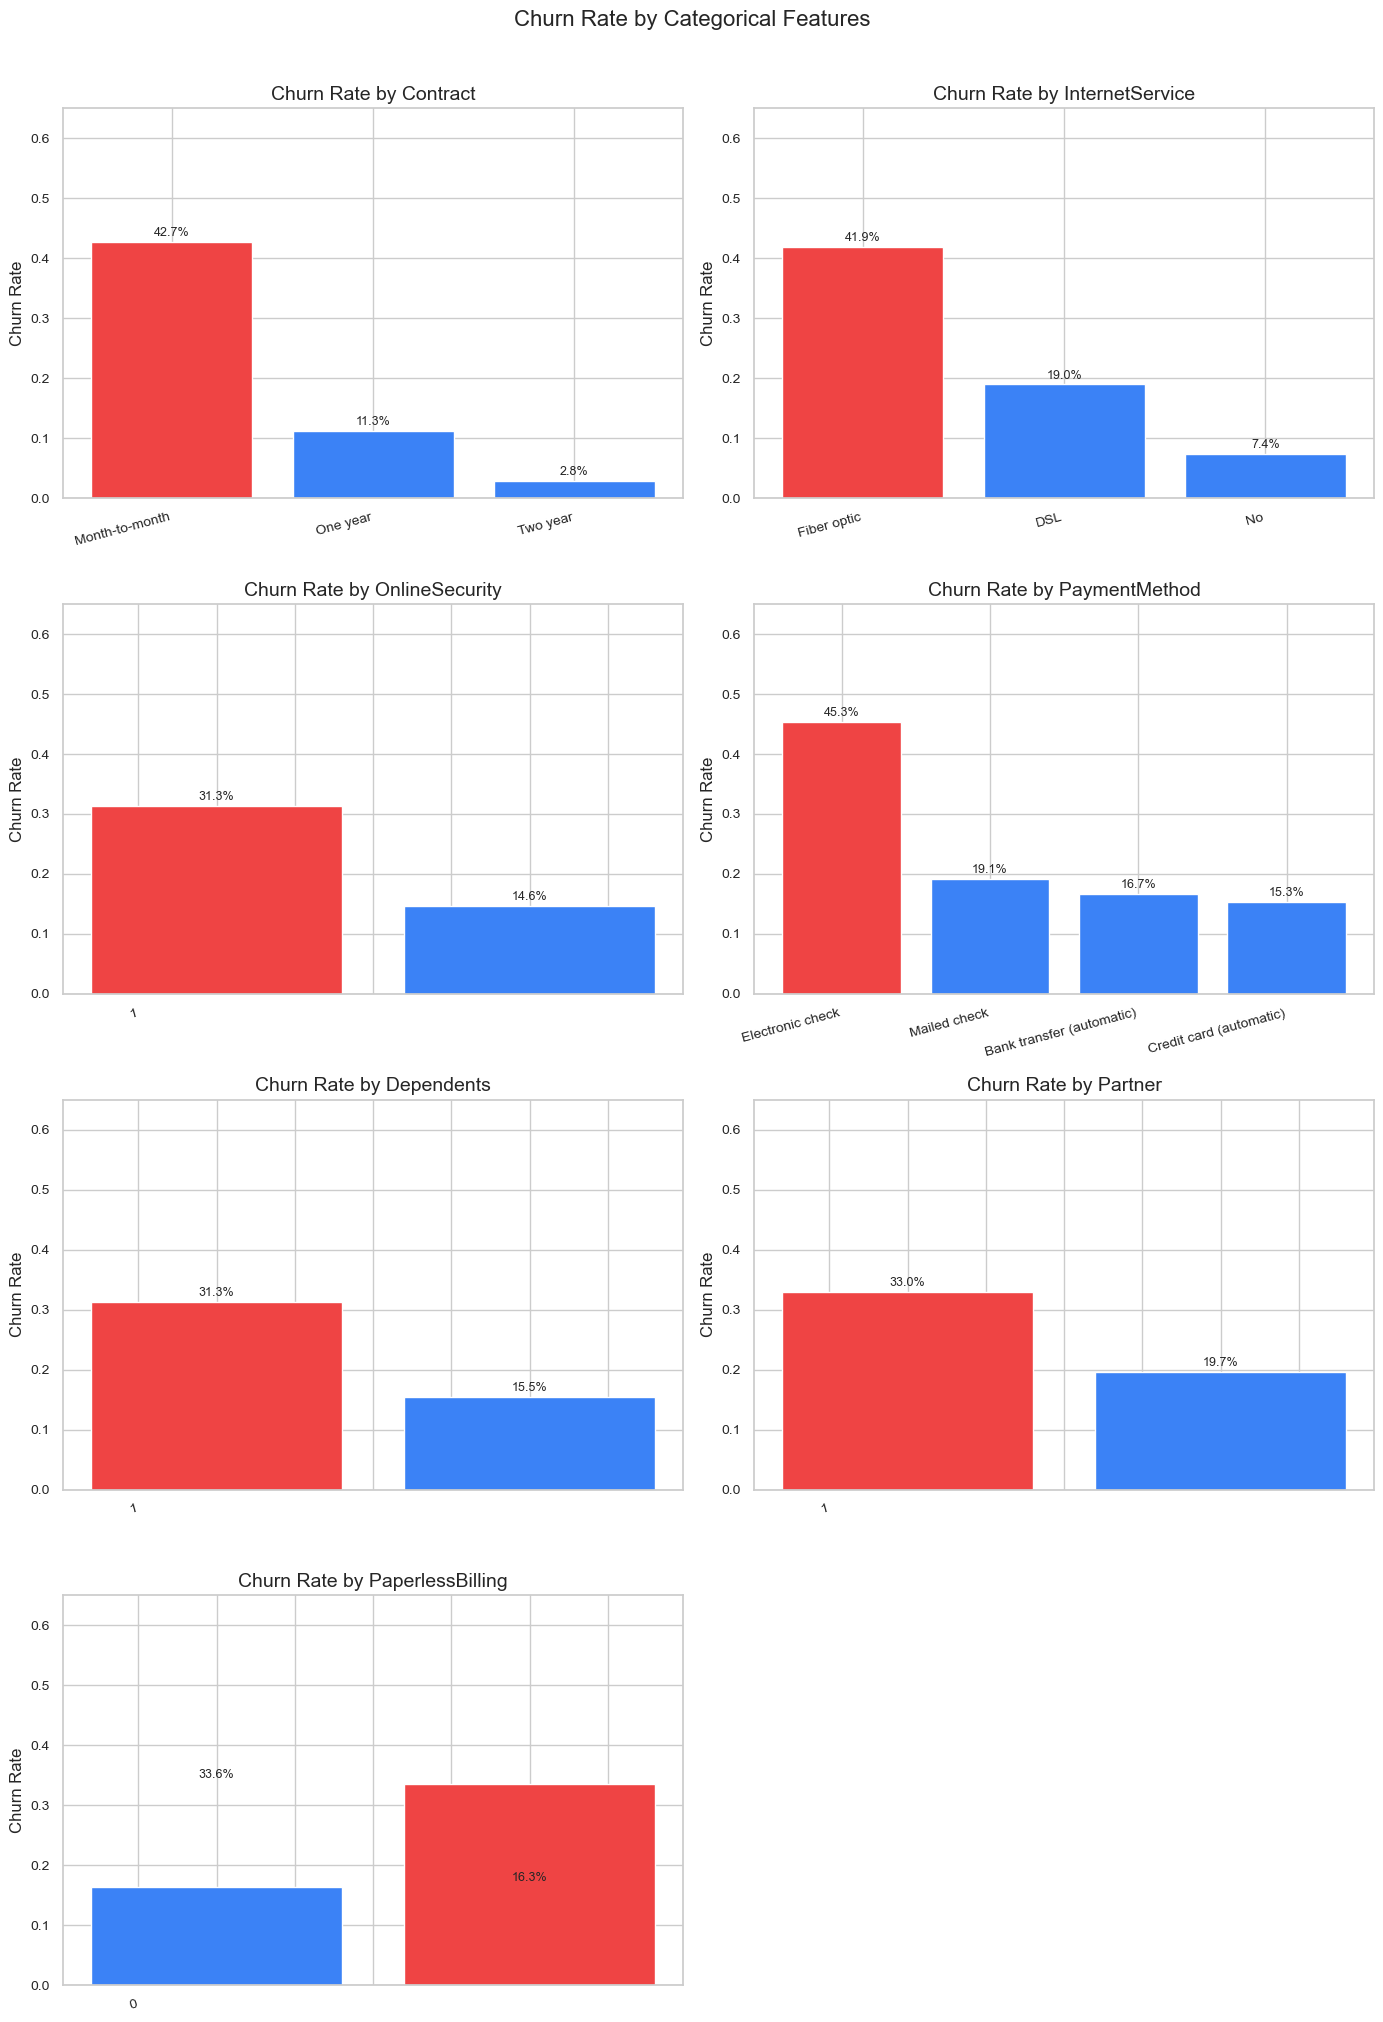

In [23]:
target_categorical_cols = [
    "Contract",        # 계약 유형 (가장 중요)
    "InternetService", # 인터넷 서비스 종류
    "OnlineSecurity",  # 온라인 보안
    "PaymentMethod",   # 결제 방법
    "Dependents",      # 부양가족 여부
    "Partner",         # 파트너 여부
    "PaperlessBilling" # 전자 청구서 여부
]

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
fig.suptitle("Churn Rate by Categorical Features", fontsize=16, y=1.01)
axes = axes.flatten()

for i, col in enumerate(target_categorical_cols):
    churn_rate = df_new.groupby(col)["Churn"].mean().sort_values(ascending=False)
    colors = ["#EF4444" if j == 0 else "#3B82F6" for j in range(len(churn_rate))]
    axes[i].bar(churn_rate.index, churn_rate.values, color=colors, edgecolor="white")
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_ylabel("Churn Rate")
    axes[i].set_ylim(0, 0.65)
    axes[i].set_xticklabels(churn_rate.index, rotation=15, ha="right")
    for j, (x, v) in enumerate(zip(churn_rate.index, churn_rate.values)):
        axes[i].text(j, v + 0.01, f"{v:.1%}", ha="center", fontsize=9)

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig("./images/categorical_churn_rates.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.2 상관관계 히트맵

수치형 변수와 인코딩된 변수 전체의 상관관계를 확인합니다.
Churn과의 상관성이 높은 변수를 파악하는 데 활용합니다.

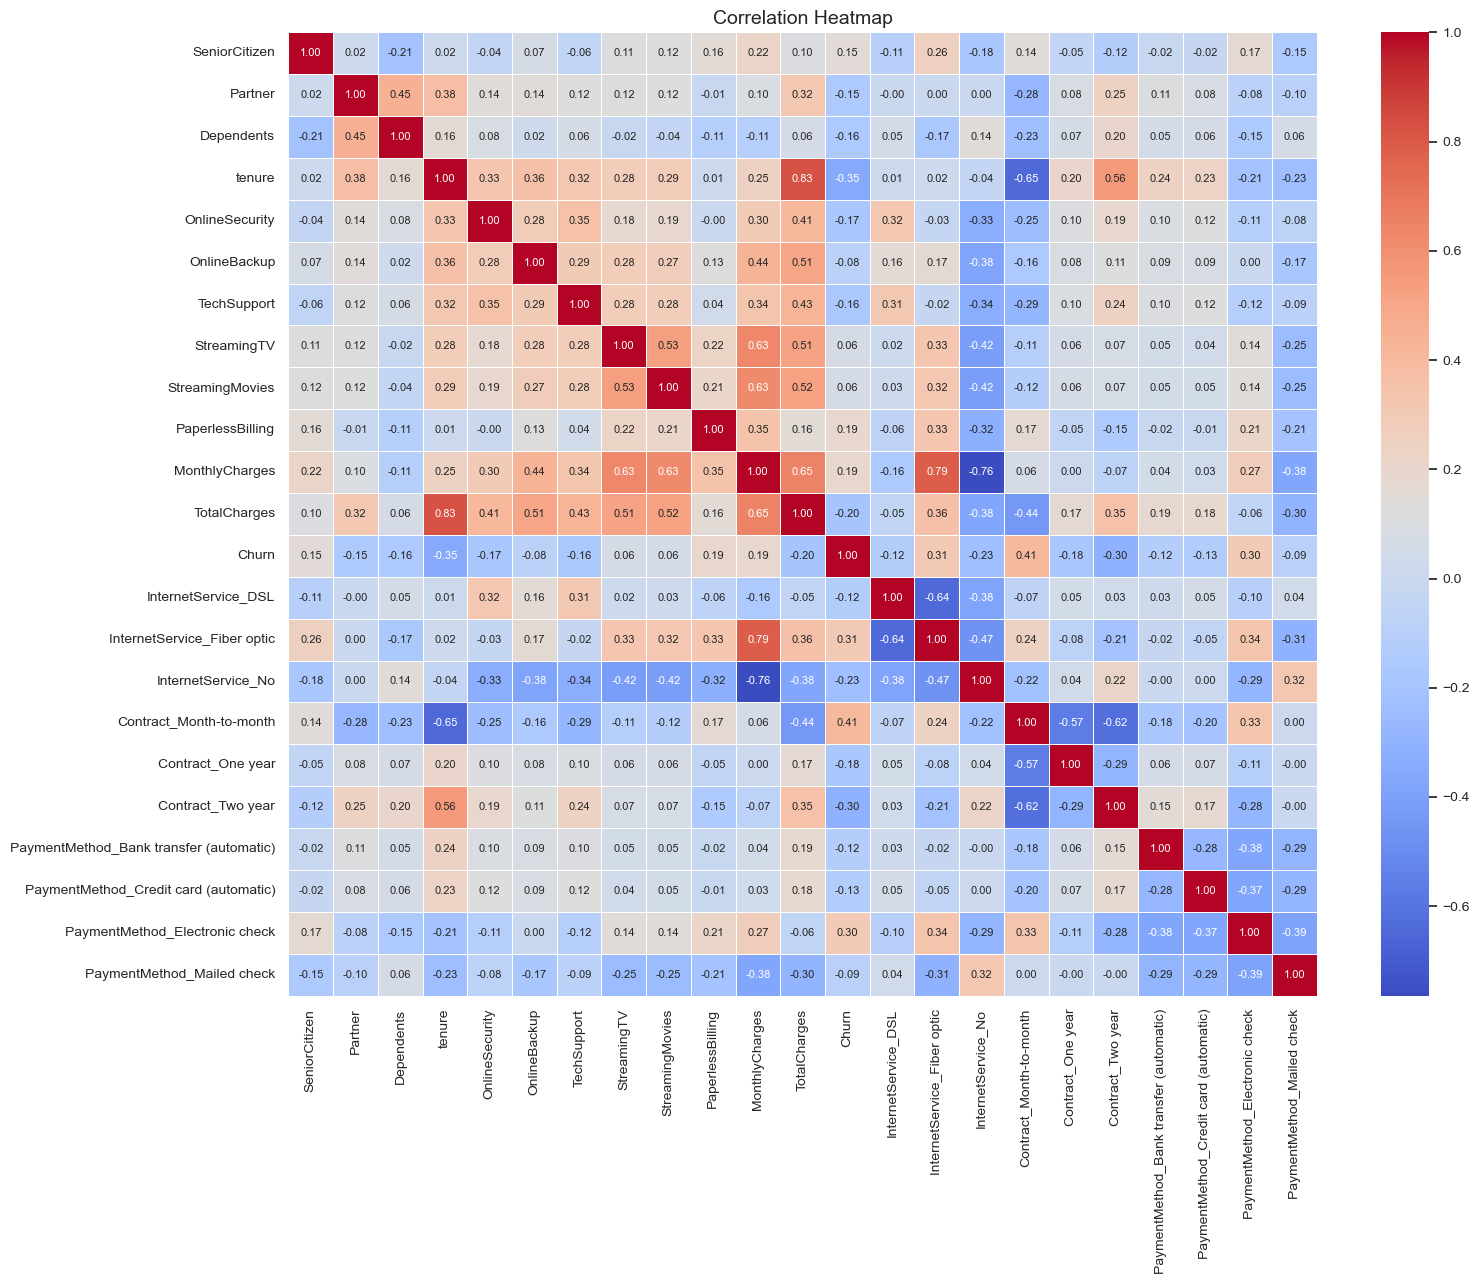

In [24]:
# 범주형 변수 원-핫 인코딩 후 상관관계 산출
df_corr = pd.get_dummies(df_new.drop(
    columns=["tenure_group", "charge_group", "Charge_Bin", "Is_MonthToMonth"],
    errors="ignore"
))
corr_matrix = df_corr.corr()

plt.figure(figsize=(16, 13))
# coolwarm: 양의 상관은 빨강, 음의 상관은 파랑으로 직관적으로 구분
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, annot_kws={"size": 8})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### 6.3 가입 기간별 이탈 분포

이탈 고객과 유지 고객의 가입 기간 분포를 비교합니다.

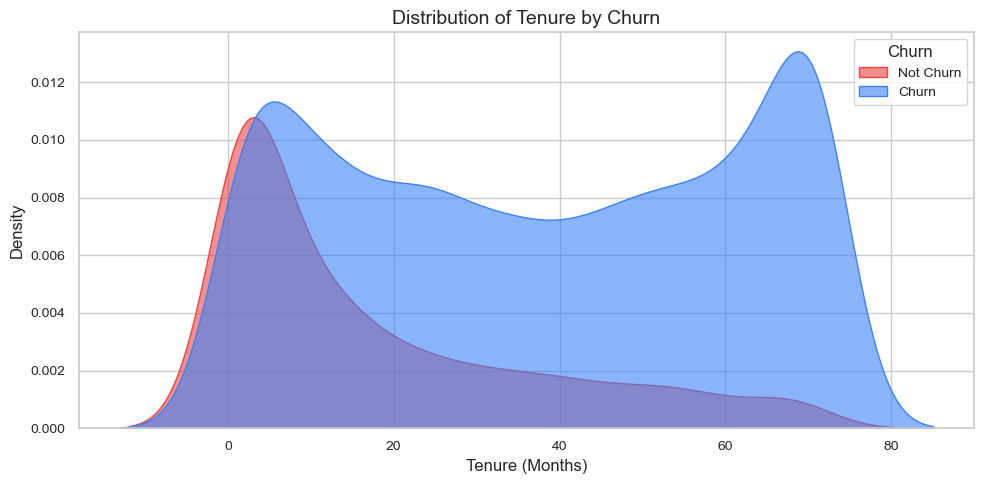

In [25]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_new, x="tenure", hue="Churn",
            fill=True, palette=CHURN_PALETTE, alpha=0.6)
plt.title("Distribution of Tenure by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Density")
plt.legend(title="Churn", labels=["Not Churn", "Churn"])
plt.tight_layout()
plt.savefig("./images/tenure_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.4 월 요금별 이탈 분포

이탈 고객과 유지 고객의 월 요금 분포를 비교합니다.

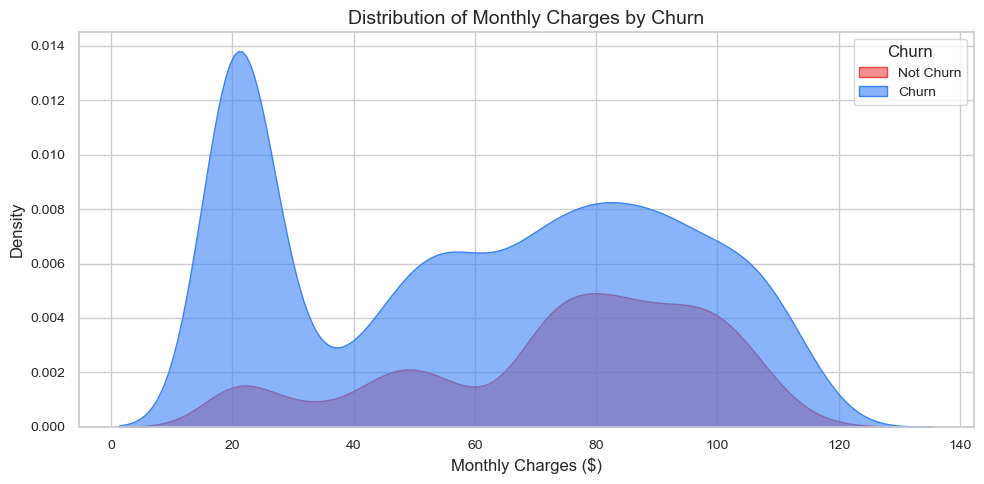

In [26]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_new, x="MonthlyCharges", hue="Churn",
            fill=True, palette=CHURN_PALETTE, alpha=0.6)
plt.title("Distribution of Monthly Charges by Churn")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Density")
plt.legend(title="Churn", labels=["Not Churn", "Churn"])
plt.tight_layout()
plt.savefig("./images/monthly_charges_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.5 월 요금 구간별 이탈률

월 요금을 $20 단위로 구간화해 구간별 이탈률을 비교합니다.
이탈률이 가장 높은 구간을 강조 표시합니다.

C:\Users\Admin\AppData\Local\Temp\ipykernel_14444\2377267581.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_bin = df_new.groupby("Charge_Bin")["Churn"].mean()


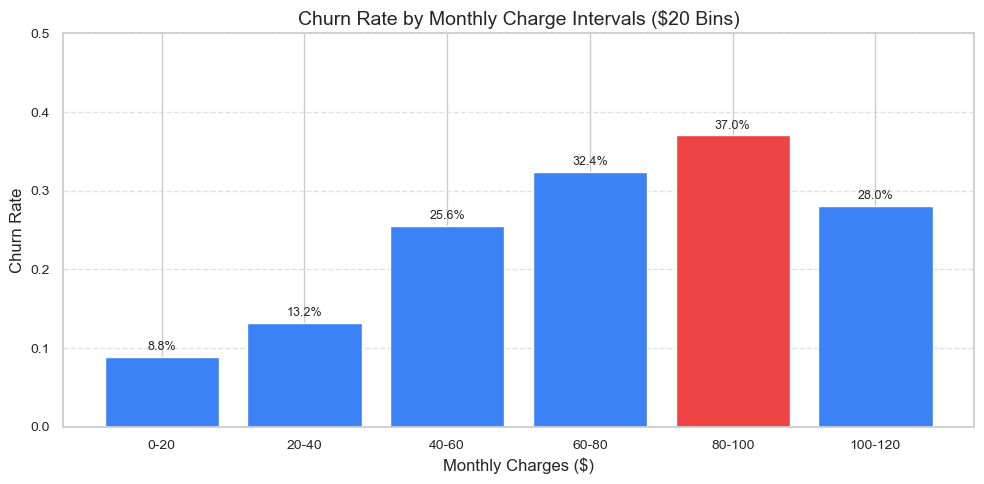

In [27]:
bins = [0, 20, 40, 60, 80, 100, 120]
labels = ["0-20", "20-40", "40-60", "60-80", "80-100", "100-120"]
df_new["Charge_Bin"] = pd.cut(df_new["MonthlyCharges"], bins=bins, labels=labels)

churn_by_bin = df_new.groupby("Charge_Bin")["Churn"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#EF4444" if v == churn_by_bin.max() else "#3B82F6" for v in churn_by_bin.values]
bars = ax.bar(churn_by_bin.index, churn_by_bin.values, color=colors, edgecolor="white")

for bar, val in zip(bars, churn_by_bin.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.1%}", ha="center", va="bottom", fontsize=9)

ax.set_title("Churn Rate by Monthly Charge Intervals ($20 Bins)")
ax.set_xlabel("Monthly Charges ($)")
ax.set_ylabel("Churn Rate")
ax.set_ylim(0, 0.5)
ax.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("./images/monthly_charges_churn.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.6 고위험군 분석: 가입 기간 × 월 요금

가입 기간과 월 요금을 함께 보면 이탈이 집중되는 고위험군을 시각적으로 파악할 수 있습니다.

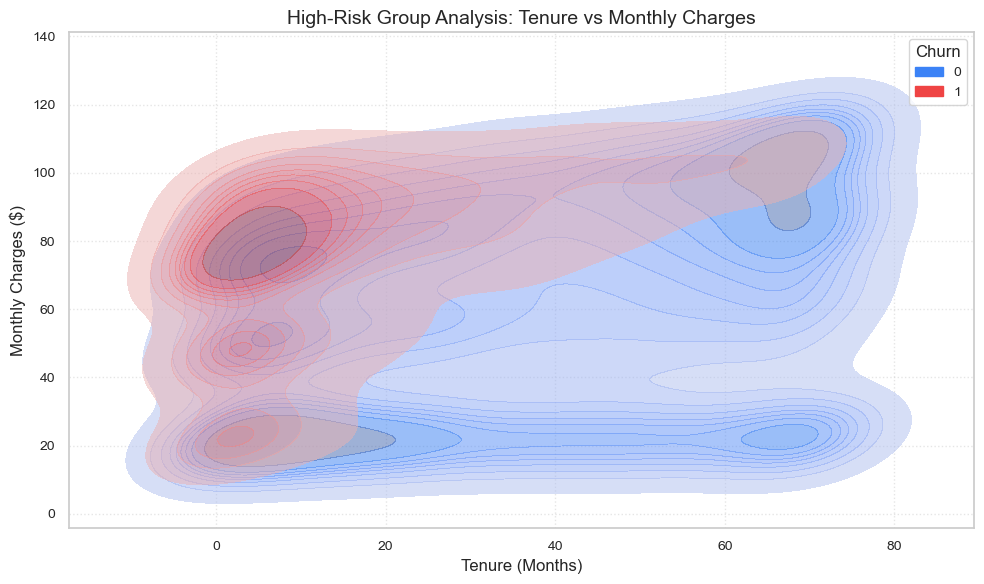

In [28]:
plt.figure(figsize=(10, 6))
# 이탈(빨강)과 유지(파랑) 분포가 겹치는 구간이 고위험군
sns.kdeplot(data=df_new, x="tenure", y="MonthlyCharges", hue="Churn",
            fill=True, alpha=0.5, palette=CHURN_PALETTE)
plt.title("High-Risk Group Analysis: Tenure vs Monthly Charges")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges ($)")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig("./images/high_risk_group.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. 결론

### 핵심 발견

| 분석 항목 | 주요 인사이트 |
|-----------|---------------|
| **이탈률** | 전체 7,043명 중 1,869명(26.5%) 이탈 |
| **계약 유형** | Month-to-month 이탈률 42.7% — 2년 계약(2.8%) 대비 약 15배 높음 |
| **가입 기간** | 이탈은 가입 초기 0~10개월에 집중, 20개월 이후 안정화 |
| **월 요금** | $80~$100 구간에서 이탈률 최고치(36.1%) 기록 |
| **평균 요금 차이** | 이탈 고객 평균 $74.4 vs 유지 고객 평균 $61.3 |
| **인터넷 서비스** | Fiber optic 이용 고객에서 이탈률 상대적으로 높음 |
| **결제 방법** | Electronic check(수동 결제) 고객의 이탈률이 가장 높음 |

### 전략적 시사점

- **단기 계약 고객 집중 관리**: Month-to-month 계약 고객에게 장기 계약 전환 인센티브 제공
- **초기 이탈 방어**: 가입 후 10개월 이내 고객을 대상으로 선제적 혜택 및 관리 강화
- **고요금 구간 리텐션**: $80 이상 고요금 고객에게 맞춤형 유지 전략 적용
- **자동 결제 전환 유도**: Electronic check 고객의 자동 결제 전환 프로모션으로 이탈 리스크 감소